In [223]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict
import json
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

In [224]:
load_dotenv()

True

In [225]:
gen_llm = ChatOllama(model= 'qwen3:0.6b', temperature=2)
#evl_llm = ChatOllama(model= 'qwen3:1.7b', temparature=0)
evl_llm = ChatGoogleGenerativeAI(model="gemini-3.6-flash", temperature=0)

In [226]:
prompt = "write a short birthday wishing message"

In [227]:
response1 = gen_llm.invoke(prompt)
print(response1)


content="🎉 Celebrating my birthday! Happy Birthday, dear [Name]! Today’s a special day—your smile is so bright, and your heart is full. Happy Birthday! 🎉❤️  \n\nRemember, life’s just a few days, but every day deserves a smile. Wishing you all the love, joy, and joy today! 💖 🌟  \n\nBest wishes, [Name]!  \n\n---  \nLet me know if you'd like to personalize further! 🌟" additional_kwargs={} response_metadata={'model': 'qwen3:0.6b', 'created_at': '2026-09-16T10:38:25.0248071Z', 'done': True, 'done_reason': 'stop', 'total_duration': 7787303700, 'load_duration': 4690800, 'prompt_eval_count': 16, 'prompt_eval_duration': 36372000, 'eval_count': 319, 'eval_duration': 7722540000, 'logprobs': None, 'model_name': 'qwen3:0.6b', 'model_provider': 'ollama'} id='lc_run--01a0a9cb-be93-70b0-adaa-bd41af5cd57e-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 16, 'output_tokens': 319, 'total_tokens': 335}


In [229]:
response2 = evl_llm.invoke(prompt)
print(response2)

c:\Users\bjit\Downloads\langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


GoogleRateLimitError: Error calling model 'gemini-3.6-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash\nPlease retry in 28.313413161s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', '

In [ ]:
question = prompt
answer = response1.content
feedback = f"""You are a strict, highly critical QA evaluator. Your job is to thoroughly critique the provided answer and assign an aggressive, accurate score. Do NOT be lenient. 

            CRITERIA FOR SCORING:
            - 9-10: Perfect, comprehensive, fully accurate, and contains zero fluff or ambiguity.
            - 7-8: Accurate and clear, but missing minor depth or could be formatted better.
            - 5-6: Technically correct but vague, incomplete, or partially unclear.
            - 1-4: Incorrect, missing key details, or unhelpful.

            QUESTION:
            {question}

            ANSWER TO EVALUATE:
            {answer}

            INSTRUCTIONS:
            1. First, analyze missing points, inaccuracies, or clarity issues.
            2. Based on your critique, determine the numerical score.
            3. Output ONLY a valid JSON object matching this schema:
            {{"score": <integer from 1 to 10>, "feedback": "<one concise sentence explaining the grade>"}}
            """

response = evl_llm.invoke(feedback)
print(response.content)

c:\Users\bjit\Downloads\langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text', 'text': '{"score": 4, "feedback": "The message inappropriately includes a Christmas tree emoji for a birthday wish, uses awkward phrasing, and contains unnecessary assistant meta-text."}', 'extras': {'signature': 'ErUWCrIWARFNMg/dvpPrFvymYwYQbuWIuyChUv9q8/Uoj7W/jwfxgWHFMhKg0XTSd4mako4fSt1jVyqTrGikdB2K+scwKf24rNU76rgeMPeMuyjuB/O8zAQ9gXyE4jrgihowsCj027Gb5iA8Y5fqfIy4pV/jn3e2dqZ8Fwk7VtGGtp8uw3Dmvc2C9uWUpHnqA46CjnV5fWcDzvxfUkJ3x4OHGZF7EJwetz9OoQD2KRVoHbA4/CgytSp7L/bvxNUwi8zu9Qfe/M+13/9wtWwV9J8w6JJiQZMQs22rHLa4DXZdyhpV4mpCm88O1GzVmtEiWNvj7MkfsioTBQqB33f8cgtgP4AFJsuvw2894aL0NiM9Fj1M5+CIrXzRWuVDzEAWtJhyjPIoqgYKGC+AJK8Q+iF9lMTC6GmuwYcAy73l3kOgZSr1ueYgaVlO05louCNpyiQ9QjPs7BqtHWLyBm7ttQSoFNgDL9koBbgdPKnncrTBOSe0ZbA2yWRc0jTVCsEZRuMfJcnB122dvJrCXCzBu4Gtl9jnP/Womx6qXx12FQdsRkTMRbK6d+Ah31Jwmb8IJc1Hc62gjnGNL3QqtNnR30Wx+4qX0VdRMufzTi4QNrzryTIKn9nedacetiyBfsU7vx2mCDBtwIkQCj75pddmGhfCiTcA+CEzBpWqXh28dPwtDn2/1iOz1HtEUvjwMMC43H6TdiyWcB0Lt/rSPrrzRnJwp7IofgyPPCzRE8mv6N84Eg3F013XggGovoegkIGW

In [ ]:

#json_response = json.loads(response.content)
json_response = json.loads(response.text)

In [ ]:
print(json_response)

{'score': 4, 'feedback': 'The message inappropriately includes a Christmas tree emoji for a birthday wish, uses awkward phrasing, and contains unnecessary assistant meta-text.'}


In [ ]:
print(type(response.content))

<class 'list'>


In [219]:
class State(TypedDict):
    question: str
    answer: str
    score: int
    feedback: str
    iteration: int

In [220]:
def generating_answer(St : State) -> State:
    question = St['question']
    answer = St['answer']
    feedback = St['feedback']
    iteration = St['iteration']

    iteration += 1

    prompt = ''
    if iteration == 1:
        prompt = f'Answer this question clearly:\n{question}'
    else :
        prompt = f"""Improve the following answer to the question based on the feedback.
                Question: {question}
                Current Answer: {answer}
                Feedback: {feedback}

                STRICT OUTPUT RULES:
                - Output ONLY the improved answer text, nothing else.
                - Do NOT mention what you improved or changed, and do NOT add any meta-commentary.
                - Do NOT include headers, labels, or titles like "Improved Answer:".
                - Do NOT give multiple options or variations — provide exactly one answer.
                - Do N
                """
        
    response = gen_llm.invoke(prompt)
    new_answer = response.content

    print(f"Iteration: {iteration}\n")
    if iteration == 1:
        print(f"Generated Answer: {new_answer}\n")
    else :
        print(f"Impoved Answer: {new_answer}\n")

    St['iteration'] = iteration
    St['answer'] = new_answer
    return St

In [ ]:
def evaluating_answer(St : State) -> State:
    question = St['question']
    answer = St['answer']

    prompt = feedback = f"""You are a strict, highly critical QA evaluator. Your job is to thoroughly critique the provided answer and assign an aggressive, accurate score. Do NOT be lenient. 

                        CRITERIA FOR SCORING:
                        - 9-10: Perfect, comprehensive, fully accurate, and contains zero fluff or ambiguity.
                        - 7-8: Accurate and clear, but missing minor depth or could be formatted better.
                        - 5-6: Technically correct but vague, incomplete, or partially unclear.
                        - 1-4: Incorrect, missing key details, or unhelpful.

                        QUESTION:
                        {question}

                        ANSWER TO EVALUATE:
                        {answer}

                        INSTRUCTIONS:
                        1. First, analyze missing points, inaccuracies, or clarity issues.
                        2. Based on your critique, determine the numerical score.
                        3. Output ONLY a valid JSON object matching this schema:
                        {{"score": <integer from 1 to 10>, "feedback": "<one concise sentence explaining the grade>"}}
                        """

    response = evl_llm.invoke(prompt)

    try:
        json_response = json.loads(response.content)
        score = int(json_response['score'])
        feedback = json_response['feedback']
    except:
        score = 1
        feedback = 'no feedback found'

    print(f'Score: {score}\n')
    print(f'Feedback: {feedback}\n')
    print('-'*50)
    print()

    St['score'] = score
    St['feedback'] = feedback

    return St  
    
    

In [222]:
def check_quality(St : State) -> State:
    if St['score'] > 7 or St['iteration'] >= 5:
        return "done"
    return "re_evl"

In [ ]:
graph = StateGraph(State)

graph.add_node("GEN_ANS", generating_answer)
graph.add_node("EVL_ANS", evaluating_answer)

graph.add_edge(START, 'GEN_ANS')
graph.add_edge('GEN_ANS', 'EVL_ANS')

graph.add_conditional_edges('EVL_ANS', check_quality, {'re_evl': 'GEN_ANS', 'done': END})

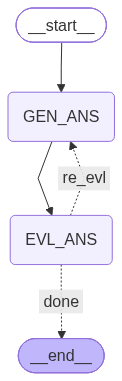

In [ ]:
graph.compile()

In [ ]:
agent = graph.compile()

In [ ]:
intial_state = {
    'question': 'what is my name',
    'iteration': 0,
    'answer': '',
    'feedback': '',
    'score': 0
}
final_state = agent.invoke(intial_state)

Iteration: 1

Generated Answer: I don't have my personal name, but if you need assistance, feel free to ask! What can I do for you?



c:\Users\bjit\Downloads\langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Score: 1

Feedback: no feedback found

--------------------------------------------------

Iteration: 2

Impoved Answer: I don't have my personal name, but if you need assistance, feel free to ask! What can I do for you?



c:\Users\bjit\Downloads\langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Score: 1

Feedback: no feedback found

--------------------------------------------------

Iteration: 3

Impoved Answer: I don't have my personal name, but if you need assistance, feel free to ask! What can I do for you?



...

Score: 1

Feedback: no feedback found

--------------------------------------------------

Iteration: 4

Impoved Answer: I don't have my personal name, but if you need assistance, feel free to ask!



c:\Users\bjit\Downloads\langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Score: 1

Feedback: no feedback found

--------------------------------------------------

Iteration: 5

Impoved Answer: If you need assistance, please let me know.



c:\Users\bjit\Downloads\langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Score: 1

Feedback: no feedback found

--------------------------------------------------



In [ ]:
print(final_state)

{'question': 'what is my name', 'answer': 'If you need assistance, please let me know.', 'score': 1, 'feedback': 'no feedback found', 'iteration': 5}
